Initial missing values in features: 105
Train rows: 961
Test rows: 255
Train missing after imputation: 0
Test missing after imputation: 0
Train-sub rows: 753
Validation rows: 208

Validation results sorted by MAE:
    window  units  dropout  batch_size  learning_rate   val_mae  val_rmse  \
12       5     32      0.4          16         0.0010  0.462443  0.638533   
8        5     32      0.3          16         0.0010  0.466697  0.669858   
15       5     32      0.4          32         0.0005  0.467538  0.646525   
10       5     32      0.3          32         0.0010  0.469646  0.643029   
9        5     32      0.3          16         0.0005  0.477493  0.677492   
14       5     32      0.4          32         0.0010  0.492027  0.680818   
4        3     32      0.4          16         0.0010  0.506285  0.754357   
0        3     32      0.3          16         0.0010  0.523998  0.751025   
2        3     32      0.3          32         0.0010  0.535086  0.747745   
5        3     3

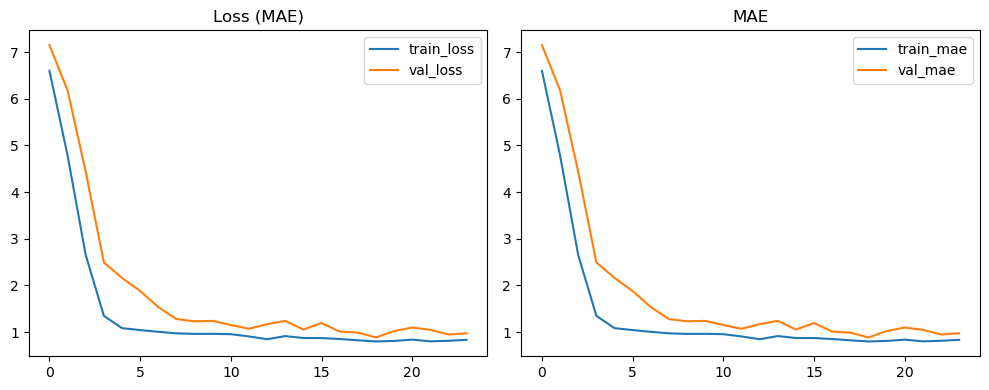

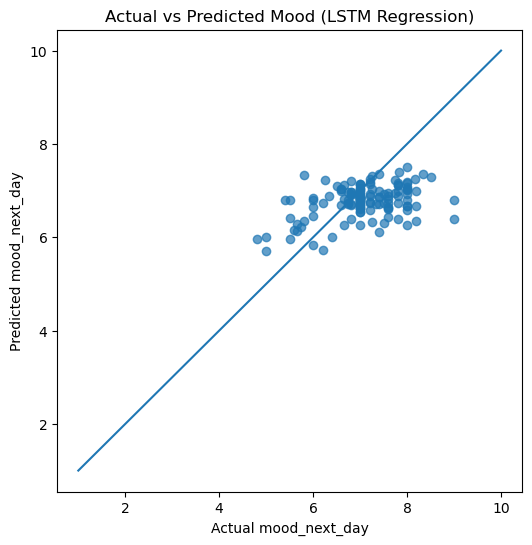

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import itertools
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================
# 1. Load model_option_A
# =========================
df = pd.read_csv("data1C/model_option_A.csv")
df["date"] = pd.to_datetime(df["date"])
df["next_date"] = pd.to_datetime(df["next_date"])
df = df.sort_values(["id", "date"]).reset_index(drop=True)

# Keep only rows with target
df = df.dropna(subset=["mood_next_day"]).copy()

# =========================
# 2. Select input features
# =========================
feature_cols = [
    "mood",
    "activity",
    "screen",
    "call",
    "sms",
    "circumplex.arousal",
    "circumplex.valence",
    "appCat.builtin",
    "appCat.communication",
    "appCat.entertainment",
    "appCat.finance",
    "appCat.game",
    "appCat.office",
    "appCat.other",
    "appCat.social",
    "appCat.travel",
    "appCat.unknown",
    "appCat.utilities",
    "appCat.weather"
]

feature_cols = [col for col in feature_cols if col in df.columns]

print("Initial missing values in features:", df[feature_cols].isna().sum().sum())

# =========================
# 3. Chronological train-test split per patient
# =========================
train_data = []
test_data = []

for patient_id, group in df.groupby("id"):
    group = group.sort_values("date").copy()

    if len(group) < 10:
        continue

    split = int(0.8 * len(group))

    if split == 0 or split == len(group):
        continue

    train_data.append(group.iloc[:split])
    test_data.append(group.iloc[split:])

train_df = pd.concat(train_data).reset_index(drop=True)
test_df = pd.concat(test_data).reset_index(drop=True)

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))

# =========================
# 4. Impute missing values separately
# =========================
interp_cols = [col for col in ["mood", "activity", "circumplex.arousal", "circumplex.valence"] if col in feature_cols]
zero_fill_cols = [col for col in feature_cols if col not in interp_cols]

for col in interp_cols:
    train_df[col] = train_df.groupby("id")[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )
    test_df[col] = test_df.groupby("id")[col].transform(
        lambda x: x.interpolate(method="linear", limit_direction="both")
    )

for col in zero_fill_cols:
    train_df[col] = train_df[col].fillna(0)
    test_df[col] = test_df[col].fillna(0)

print("Train missing after imputation:", train_df[feature_cols].isna().sum().sum())
print("Test missing after imputation:", test_df[feature_cols].isna().sum().sum())

# =========================
# 5. Create train/validation split from training data
# =========================
train_sub_parts = []
val_parts = []

for patient_id, group in train_df.groupby("id"):
    group = group.sort_values("date").copy()

    if len(group) < 8:
        continue

    split = int(len(group) * 0.8)

    if split == 0 or split == len(group):
        continue

    train_sub_parts.append(group.iloc[:split])
    val_parts.append(group.iloc[split:])

train_sub_df = pd.concat(train_sub_parts).reset_index(drop=True)
val_df = pd.concat(val_parts).reset_index(drop=True)

print("Train-sub rows:", len(train_sub_df))
print("Validation rows:", len(val_df))

# =========================
# 6. Scale features
# =========================
scaler = StandardScaler()

train_sub_df[feature_cols] = scaler.fit_transform(train_sub_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])
test_df_scaled = test_df.copy()
test_df_scaled[feature_cols] = scaler.transform(test_df_scaled[feature_cols])

# =========================
# 7. Build sequences
# =========================
def build_sequences(dataframe, feature_cols, target_col, window=5):
    X, y = [], []

    for patient_id, group in dataframe.groupby("id"):
        group = group.sort_values("date").reset_index(drop=True)

        if len(group) < window:
            continue

        values = group[feature_cols].values
        targets = group[target_col].values
        dates = pd.to_datetime(group["date"]).values

        for i in range(window - 1, len(group)):
            seq_dates = pd.to_datetime(dates[i - window + 1:i + 1])
            diffs = np.diff(seq_dates).astype("timedelta64[D]").astype(int)

            # only keep truly consecutive daily windows
            if not np.all(diffs == 1):
                continue

            X.append(values[i - window + 1:i + 1])
            y.append(targets[i])

    return np.array(X), np.array(y, dtype=np.float32)

# =========================
# 8. Define LSTM regression model
# =========================
def make_lstm_regressor(input_shape, units=32, dropout=0.3, learning_rate=0.001):
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.LSTM(units),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1, activation="linear")
    ])

    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="mae",
        metrics=[
            tf.keras.metrics.MeanAbsoluteError(name="mae"),
            tf.keras.metrics.RootMeanSquaredError(name="rmse")
        ]
    )
    return model

# =========================
# 9. Hyperparameter tuning on validation MAE
# =========================
param_grid = {
    "window": [3, 5],
    "units": [32],
    "dropout": [0.3, 0.4],
    "batch_size": [16, 32],
    "learning_rate": [0.001, 0.0005]
}

results = []

for window, units, dropout, batch_size, learning_rate in itertools.product(
    param_grid["window"],
    param_grid["units"],
    param_grid["dropout"],
    param_grid["batch_size"],
    param_grid["learning_rate"]
):
    X_train_sub, y_train_sub = build_sequences(
        train_sub_df, feature_cols, "mood_next_day", window=window
    )
    X_val, y_val = build_sequences(
        val_df, feature_cols, "mood_next_day", window=window
    )

    if len(X_train_sub) == 0 or len(X_val) == 0:
        continue

    model = make_lstm_regressor(
        input_shape=(X_train_sub.shape[1], X_train_sub.shape[2]),
        units=units,
        dropout=dropout,
        learning_rate=learning_rate
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    model.fit(
        X_train_sub,
        y_train_sub,
        validation_data=(X_val, y_val),
        epochs=30,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    y_val_pred = model.predict(X_val, verbose=0).flatten()

    val_mae = mean_absolute_error(y_val, y_val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
    val_r2 = r2_score(y_val, y_val_pred)

    results.append({
        "window": window,
        "units": units,
        "dropout": dropout,
        "batch_size": batch_size,
        "learning_rate": learning_rate,
        "val_mae": val_mae,
        "val_rmse": val_rmse,
        "val_r2": val_r2
    })

results_df = pd.DataFrame(results).sort_values("val_mae", ascending=True)
print("\nValidation results sorted by MAE:")
print(results_df)

# =========================
# 10. Select best hyperparameters
# =========================
best = results_df.iloc[0]

best_window = int(best["window"])
best_units = int(best["units"])
best_dropout = float(best["dropout"])
best_batch_size = int(best["batch_size"])
best_learning_rate = float(best["learning_rate"])

print("\nBest parameters:")
print(best)

# =========================
# 11. Refit scaler on full train set
# =========================
scaler_final = StandardScaler()

train_df_scaled = train_df.copy()
test_df_scaled = test_df.copy()

train_df_scaled[feature_cols] = scaler_final.fit_transform(train_df_scaled[feature_cols])
test_df_scaled[feature_cols] = scaler_final.transform(test_df_scaled[feature_cols])

# =========================
# 12. Build final train and test sequences
# =========================
X_train, y_train = build_sequences(
    train_df_scaled, feature_cols, "mood_next_day", window=best_window
)
X_test, y_test = build_sequences(
    test_df_scaled, feature_cols, "mood_next_day", window=best_window
)

print("\nFinal train shape:", X_train.shape, y_train.shape)
print("Final test shape:", X_test.shape, y_test.shape)

# =========================
# 13. Train final model
# =========================
final_model = make_lstm_regressor(
    input_shape=(X_train.shape[1], X_train.shape[2]),
    units=best_units,
    dropout=best_dropout,
    learning_rate=best_learning_rate
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = final_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=best_batch_size,
    callbacks=[early_stop],
    verbose=1
)

# =========================
# 14. Evaluate on test set
# =========================
y_pred = final_model.predict(X_test, verbose=0).flatten()

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nFinal LSTM Regression Performance on Test Set:")
print("MAE :", round(mae, 4))
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("R^2 :", round(r2, 4))

# Optional: clip predictions to valid mood range
y_pred_clipped = np.clip(y_pred, 1, 10)

mae_clipped = mean_absolute_error(y_test, y_pred_clipped)
mse_clipped = mean_squared_error(y_test, y_pred_clipped)
rmse_clipped = np.sqrt(mse_clipped)
r2_clipped = r2_score(y_test, y_pred_clipped)

print("\nClipped Predictions Performance (range 1-10):")
print("MAE :", round(mae_clipped, 4))
print("MSE :", round(mse_clipped, 4))
print("RMSE:", round(rmse_clipped, 4))
print("R^2 :", round(r2_clipped, 4))

# =========================
# 15. Plot training history
# =========================
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.title("Loss (MAE)")

plt.subplot(1, 2, 2)
plt.plot(history.history["mae"], label="train_mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.legend()
plt.title("MAE")

plt.tight_layout()
plt.show()

# =========================
# 16. Plot actual vs predicted
# =========================
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_clipped, alpha=0.7)
plt.plot([1, 10], [1, 10])
plt.xlabel("Actual mood_next_day")
plt.ylabel("Predicted mood_next_day")
plt.title("Actual vs Predicted Mood (LSTM Regression)")
plt.show()